<a href="https://colab.research.google.com/github/TechJas/CAFE-DATA-ANALYSIS/blob/main/cafeCRUNCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.


In [3]:
import os
path = os.path.join(path,'dirty_cafe_sales.csv')

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(path)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [6]:
df.shape

(10000, 8)

In [7]:
df.head()


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [9]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [10]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [11]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [12]:
df['Transaction Date']

,Transaction Date
0,2023-09-08
1,2023-05-16
2,2023-07-19
3,2023-04-27
4,2023-06-11
...,...
9995,2023-08-30
9996,2023-06-02
9997,2023-03-02
9998,2023-12-02


# Fix the Invalid Date Format
This converts invalid dates into NaT (Not a Time) by using below format of syntax.

In [13]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [14]:
df[df['Transaction Date'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
11,TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,NaT
29,TXN_7640952,Cake,4,3.0,12.0,Digital Wallet,Takeaway,NaT
33,TXN_7710508,UNKNOWN,5,1.0,5.0,Cash,NaN,NaT
77,TXN_2091733,Salad,1,5.0,5.0,NaN,In-store,NaT
103,TXN_7028009,Cake,4,3.0,12.0,NaN,Takeaway,NaT
...,...,...,...,...,...,...,...,...
9933,TXN_9460419,Cake,1,3.0,3.0,NaN,Takeaway,NaT
9937,TXN_8253472,Cake,1,3.0,3.0,NaN,NaN,NaT
9949,TXN_3130865,Juice,3,3.0,9.0,NaN,In-store,NaT
9983,TXN_9226047,Smoothie,3,4.0,12.0,Cash,NaN,NaT


Total rows = 10,000

Columns = 8

Rows with invalid / null Transaction Date = 460

Let’s calculate the percentage of bad rows.

 460
/
10000 =
   0.046



That means 4.6% of the data is invalid.

There are three decision questions professionals ask:

# **Question 1**

Is the missing data small or large?

**Rule of thumb:**

Missing %	  ----    Action :

< 5%	------ Usually safe to drop

5–20% ------	Investigate carefully

> more than 20%	---- Avoid dropping

Your case:

4.6% → small

So dropping is usually safe.

# Question 2

Is the column important for analysis?

Your column = Transaction Date

You will use it for:

monthly sales

daily trends

seasonality


If the date is invalid, that row cannot be used for time analysis anyway.

So keeping it adds noise.

# Question 3

Can the missing value be reliably reconstructed?

For dates, usually NO.

Example:

If a row has:

Item ---Quantity---Total Spent---Date


Coffee-----	  2	---------         120------	???

There is no safe way to guess the date.

So filling it with a fake date would create false trends.

In [15]:
df = df.dropna(subset=['Transaction Date'])

# Creating Useful Features IN Date

In [16]:
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day

/tmp/ipykernel_312/3635344808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Transaction Date'].dt.year
/tmp/ipykernel_312/3635344808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Transaction Date'].dt.month
/tmp/ipykernel_312/3635344808.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

> # Quantity

In [17]:
df['Quantity'].unique()

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [18]:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')

/tmp/ipykernel_312/1668668153.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')


In [19]:
df['Quantity'].isna()

,Quantity
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [20]:
df['Quantity'].isnull().sum()

np.int64(454)

Total rows = 10,000

Columns = 8

Rows with invalid / null Quantity = 454

Let’s calculate the percentage of bad rows.

454
/
10000 =
   0.0454



That means 4.54% of quantity is invalid.

so we can able to drop that no worry

In [21]:
df = df.dropna(subset = ['Quantity'])

>### In day-to-day analysis, we work with the transaction date, which helps us perform time-based analysis. From the transaction date, we can extract useful information such as the month, which allows us to analyze trends and patterns over time.

>>### The quantity field is important for calculations such as total sales, revenue analysis, and customer spending metrics. Therefore, the quantity must be in numeric format. If it is stored as a non-numeric value, mathematical operations like summation or multiplication cannot be performed correctly.

>>### For this reason, we convert the Quantity column into a numeric data type to ensure that all calculations and analyses can be performed without errors.*

**Convert Price Per Unit to numeric:**

In [22]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

**Convert Total Spent to numeric:**

In [23]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [24]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,float64
Price Per Unit,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]
Year,int32
Month,int32


In [25]:
df = df.dropna(subset=['Price Per Unit'])

In [26]:
print(df['Payment Method'].unique())

['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]


In [27]:
df['Payment Method']

,Payment Method
0,Credit Card
1,Cash
2,Credit Card
3,UNKNOWN
4,Digital Wallet
...,...
9993,Cash
9994,NaN
9995,NaN
9997,Digital Wallet


# New section  The Standard Formula

First calculate the Interquartile Range (IQR):

IQR=Q3−Q1

Then compute the boundaries:

Lower boundary




Q1−1.5×IQR

Upper boundary





Q3+1.5×IQR

Now classify values:

Value < Lower boundary → Outlier

Value > Upper boundary → Outlier

Values inside the range → Normal data

Why 1.5?

The 1.5 multiplier is not random. It was chosen because it works well for many real-world datasets.

It captures most normal variation

But still flags extreme unusual values

If we used a smaller multiplier like 1, we would detect too many outliers.
If we used 3, we would detect only extremely extreme points.

Sometimes analysts also use:


Q1−3×IQR

Q3+3×IQR

These are called extreme outliers.



Dataset:

```
2, 4, 6, 8, 10, 12, 50
```

First rule: **Data must be sorted** (ascending order).
This dataset is already sorted.

---

# Step 1 — Find the Median (Q2)

Count numbers:

```
7 values
```

Median position formula:

[
(n+1)/2
]

[
(7+1)/2 = 4
]

So the **4th value** is the median.

```
2, 4, 6, 8, 10, 12, 50
         ↑
      Median
```

Therefore:

```
Q2 = 8
```

---

# Step 2 — Find Q1 (Lower Quartile)

Take the numbers **before the median**.

```
2, 4, 6
```

Now find the median of this group.

Middle value:

```
4
```

So:

```
Q1 = 4
```

---

# Step 3 — Find Q3 (Upper Quartile)

Take the numbers **after the median**.

```
10, 12, 50
```

Find the median of this group.

Middle value:

```
12
```

So:

```
Q3 = 12
```

---

# Final Quartiles

| Quartile    | Value |
| ----------- | ----- |
| Q1          | 4     |
| Q2 (Median) | 8     |
| Q3          | 12    |

---

# Now Calculate IQR

[
IQR = Q3 - Q1
]

[
12 - 4 = 8
]

---

# Outlier Boundaries

Lower limit:

[
4 - 1.5(8) = -8
]

Upper limit:

[
12 + 1.5(8) = 24
]

Now check dataset:

```
2,4,6,8,10,12,50
```

Since

```
50 > 24
```

👉 **50 is an outlier**

---

# One Important Insight

Notice something interesting:

If the dataset was

```
2,4,6,8,10,12,14
```

Then:

```
Q1 = 4
Q3 = 12
IQR = 8
Upper limit = 24
```

Here **14 would NOT be an outlier**.

So the IQR method **protects normal variation but detects extreme values**.

---

If you want, I can also show you **why pandas sometimes gives slightly different Q1/Q3 values using interpolation in the `quantile()` function of pandas in Python.**
This is actually the reason many students get confused during EDA in notebooks like Google Colab.


In [28]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_quantity = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

print("\nOutliers in Quantity column:")
print(outliers_quantity[['Transaction ID', 'Item', 'Quantity']])

Q1 (25th percentile): 2.0
Q3 (75th percentile): 4.0
IQR (Interquartile Range): 2.0
Lower Bound for Outliers: -1.0
Upper Bound for Outliers: 7.0

Outliers in Quantity column:
Empty DataFrame
Columns: [Transaction ID, Item, Quantity]
Index: []


In [29]:
df['Quantity'].describe()

,Quantity
count,8596.000000
mean,3.020358
std,1.417477
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [30]:
df[['Quantity','Price Per Unit','Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,8596.000000,8596.000000,8159.000000
mean,3.020358,2.951547,8.910957
std,1.417477,1.276884,5.993071
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [31]:
df['Quantity'].isnull().sum()

np.int64(0)

In [32]:
df['Payment Method'].isnull().sum()

np.int64(2188)

In [33]:
df['Payment Method'].unique()



array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan],
      dtype=object)





In a transaction dataset, purchases are typically completed using valid payment methods such as **Cash, Credit Card, or Digital Wallet**. These represent the actual ways customers pay for products or services.

--------

However, the dataset also contains values like **"UNKNOWN"** and **"ERROR"** in the **Payment Method** column. These values do not represent real payment methods. They may occur due to system issues, data entry mistakes, or transaction processing errors.

Since these values do not reflect actual payment behavior, including them in the analysis could lead to incorrect insights about payment method usage. Therefore, these invalid entries should be either removed or replaced with null values before performing the analysis.

By cleaning these values, we ensure that the payment method analysis is based only on valid and meaningful transaction data.

---

✅ **Short version (good for interview or presentation):**

> Invalid payment methods such as "UNKNOWN" or "ERROR" do not represent real payment options and may result from system or data entry errors. To maintain data accuracy, these values are excluded or replaced with null values before performing the analysis.

---

If you want, I can also help you **write a clean explanation for all your data cleaning steps (date conversion, quantity numeric, payment method validation, outlier check)** so your project explanation sounds very professional.


In [34]:
valid_methods = ['Credit Card', 'Cash', 'Digital Wallet']

df.loc[~df['Payment Method'].isin(valid_methods), 'Payment Method'] = None

In [35]:
df['Payment Method'].value_counts()

,count
Payment Method,
Digital Wallet,1980
Cash,1957
Credit Card,1955


In [36]:
df.dropna(subset=['Payment Method'],inplace=True)

>    > Invalid payment methods were replaced with null values, and rows containing null values were removed using dropna() to ensure only valid transactions were included in the analysis.

✅ Insight: understand preferred payment methods and impact on revenue.

In [75]:
#Revenue per payment method:
payment_revenue = df.groupby('Payment Method')['Total Spent'].sum()
print(payment_revenue)

Payment Method
Cash              9081.5
Credit Card       8851.0
Digital Wallet    9673.0
Name: Total Spent, dtype: float64


In [37]:
df['Year']

,Year
0,2023
1,2023
2,2023
4,2023
5,2023
...,...
9990,2023
9991,2023
9993,2023
9997,2023


#✅ Simple explanation for your project

To determine the month with the highest sales, the transaction date was converted into datetime format and the month was extracted.


 The dataset was then grouped by month and the total sales were calculated to identify the month with the maximum revenu

In [38]:
df['Month']

,Month
0,9
1,5
2,7
4,6
5,3
...,...
9990,5
9991,2
9993,10
9997,3


In [39]:
#: #Insight: Identify peak sales months.
"""2️⃣ Monthly Sales Trend"""
#Calculate Total Sales Per Month
monthly_sales = df.groupby('Month')['Total Spent'].sum()

In [40]:

monthly_sales.idxmax() #Find the Month with Highest Sales

np.int32(6)

In [41]:
print(monthly_sales)

Month
1     4251.0
2     3945.5
3     4281.0
4     4020.0
5     3815.5
6     4456.5
7     4150.5
8     4436.0
9     4324.0
10    4287.0
11    4228.0
12    4204.0
Name: Total Spent, dtype: float64


In [87]:
# Quantity sold per month
monthly_quantity = df.groupby('Month')['Quantity'].sum().sort_values(ascending=False)
print(monthly_quantity)

Month
1     957.0
11    871.0
10    860.0
9     845.0
12    812.0
4     805.0
7     802.0
6     796.0
2     790.0
3     786.0
8     781.0
5     685.0
Name: Quantity, dtype: float64


<Axes: xlabel='Month'>

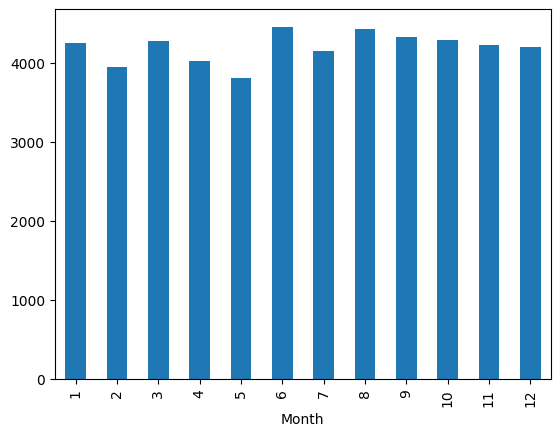

In [42]:
monthly_sales.plot(kind='bar')

#YEARLY SALES:

In [43]:
yearly_sales =df.groupby('Year')['Total Spent'].sum()

In [44]:
yearly_sales.idxmax()

np.int32(2023)

In [45]:
print(yearly_sales)

Year
2023    50399.0
Name: Total Spent, dtype: float64


<Axes: >

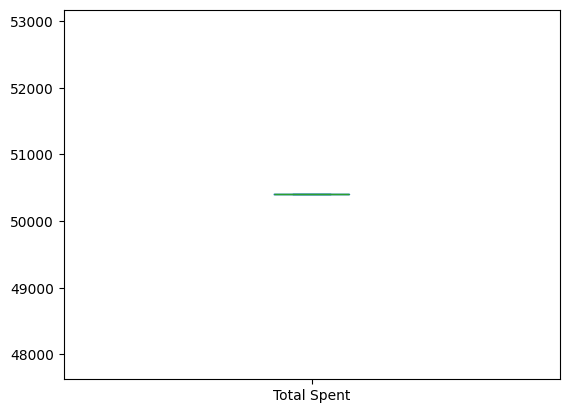

In [46]:
yearly_sales.plot(kind='box')

In [47]:
daily_sales=df.groupby('Transaction Date')['Total Spent'].sum()

In [48]:
daily_sales.idxmax()

Timestamp('2023-11-07 00:00:00')

In [49]:
print(daily_sales)

Transaction Date
2023-01-01    111.5
2023-01-02     99.0
2023-01-03     74.0
2023-01-04    160.5
2023-01-05    225.0
              ...  
2023-12-27    153.0
2023-12-28    141.0
2023-12-29     95.5
2023-12-30    112.0
2023-12-31     57.0
Name: Total Spent, Length: 365, dtype: float64


5️⃣ Time-Based Analysis

Daily / weekly trends:

In [82]:
df['Day'] = df['Transaction Date'].dt.day_name()
daily_revenue = df.groupby('Day')['Total Spent'].sum().sort_values(ascending=False) #descending order based sorted and identiffy here by, monday has large renuve genrated
print(daily_revenue)

Day
Monday       4205.0
Thursday     4080.0
Sunday       4061.5
Tuesday      3988.0
Saturday     3923.5
Friday       3788.0
Wednesday    3559.5
Name: Total Spent, dtype: float64


In [79]:
#1️⃣ Total Sales Analysis

"""Find total revenue generated."""
total_sales = df['Total Spent'].sum()
print(total_sales)

27605.5


In [51]:
df['Item'].isnull().sum()

np.int64(194)

In [52]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Smoothie', 'Sandwich', 'Salad',
       'Juice', nan, 'UNKNOWN', 'ERROR', 'Tea'], dtype=object)

In [53]:
validity = ['Coffee', 'Cake', 'Cookie', 'Smoothie', 'Sandwich', 'Salad',
       'Juice','Tea']

df.loc[~df['Item'].isin(validity), 'Item'] = None

WE can allow to drop null values or non format values in items.since there wont be any error ,nan,unknown kinds of values.
total non valid or null values is 194 and total columns is 10000.
so, (194/10000) * 100% = 1.94 %
we allow to drop the values.

In [54]:
df.dropna(subset=['Item'],inplace=True)

In [55]:
df["Item"].value_counts()

,count
Item,
Juice,728
Salad,703
Cake,682
Sandwich,651
Coffee,649
Cookie,646
Smoothie,644
Tea,616


In [56]:
#3️⃣ Most Sold Item. Find which product sells the most.
"""Infers  : Shows popular products."""
items_bought = df.groupby('Item')['Quantity'].sum()   #ascending order basis sorted
print(items_bought)

Item
Cake        2100.0
Coffee      1964.0
Cookie      1917.0
Juice       2138.0
Salad       2112.0
Sandwich    1982.0
Smoothie    1992.0
Tea         1884.0
Name: Quantity, dtype: float64


In [72]:
#Revenue by item:
item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
print(item_revenue)

Item
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Juice       3735.0
Cake        3519.0
Coffee      2242.0
Tea         1726.5
Cookie      1163.0
Name: Total Spent, dtype: float64


In [57]:
#5️⃣ Location-Based Sales
df['Location'].isnull().sum()

np.int64(1706)

In [58]:
df['Location'].unique()

array(['Takeaway', 'In-store', nan, 'UNKNOWN', 'ERROR'], dtype=object)

In [65]:
 #1️⃣ First Understand Your Current Code
val = ['Takeaway', 'In-store']

df.loc[~df['Location'].isin(val), 'Location'] = None

In [66]:
df['Location'].value_counts()

,count
Location,
Takeaway,1618
In-store,1616


In [67]:
df.dropna(subset=['Location'],inplace = True)

In [68]:
df.shape

(3234, 11)

You are thinking in the correct **EDA decision process**: first measure the problem (17.6% invalid), then decide whether to **clean, replace, or drop**. Let’s structure it clearly.

---


### What this does

`~df['Location'].isin(val)`
means:

> find values **NOT in the allowed list**

Then:

```
Location = None
```

So **invalid locations become null values**.

---

# 2️⃣ Now You Said

```
invalid rows = 1706
total rows = 10000
≈ 17.6%
```

In EDA, this is a **moderate missing percentage**.

Typical rule:

| Missing % | Action                           |
| --------- | -------------------------------- |
| 0–5%      | Drop rows                        |
| 5–20%     | Decide based on importance       |
| 20%+      | Usually fill / analyze carefully |

So **17.6% can still be dropped safely** if Location is not critical.

---

# 3️⃣ Correct Way to Drop These Rows

First convert invalid values to `NaN`.

Better code:

```python
val = ['Takeaway', 'In-store']

df.loc[~df['Location'].isin(val), 'Location'] = None
```

Now drop rows with missing location:

```python
df.dropna(subset=['Location'], inplace=True)
```

---

# 4️⃣ Confirm Rows Were Removed

Check before and after.

```
print(df.shape)
```




---

# 5️⃣ Now Run Your Analysis

Now you can safely do:

```python
location_sales = df.groupby('Location')['Total Spent'].sum()

print(location_sales)
```

Example output:

```
In-store    52000
Takeaway    31000
```

This tells you **which location type generates more revenue**.

---

# 6️⃣ Important Logical Correction

You wrote `'nan'` inside your valid list.

```
'nan'
```

is **not the same as**

```
np.nan
```

So **remove it from the list**.

Correct list:

```python
val = ['Takeaway', 'In-store']
```

---

# 7️⃣ A Cleaner Professional Approach (Recommended)

Instead of converting then dropping:

```python
val = ['Takeaway','In-store']

df = df[df['Location'].isin(val)]
```

This **directly keeps valid rows**.

---

# 8️⃣ One More Analytical Step (Very Useful)

Check the **percentage of invalid data**.

```python
invalid_percent = df['Location'].isna().sum() / len(df) * 100
print(invalid_percent)
```

This is often required in **EDA reports**.

Example:

```
Missing Location values = 17.6%
Rows removed during cleaning
```

---

# 📊 The Analytical Insight You Should Write

Example conclusion:

> Approximately **17.6% of Location entries contained invalid values such as UNKNOWN or ERROR. These rows were removed to maintain dataset reliability before performing location-based sales analysis.**

---

✅ If you want, I can also show you **3 powerful EDA checks professors expect but most students miss**, like:

* detecting **hidden typos in categorical columns**
* checking **data leakage in sales columns**
* identifying **fake outliers in transaction datasets**

These are **very common mistakes in beginner EDA**.


✅Insight:

Which item is most popular in each month

Detect seasonal patterns in item sales (like smoothies in summer, coffee in winter)

In [88]:
item_month = df.pivot_table(values='Quantity', index='Item', columns='Month', aggfunc='sum')
print(item_month)

Month        1      2      3      4      5      6      7      8      9   \
Item                                                                      
Cake      146.0   84.0   78.0   88.0   71.0   95.0  104.0  119.0  102.0   
Coffee     92.0   93.0   98.0   93.0   79.0  107.0  126.0   74.0   64.0   
Cookie    121.0   91.0  108.0   76.0  107.0   89.0  105.0  102.0  110.0   
Juice     123.0  117.0   91.0  126.0  104.0  103.0   75.0  102.0  104.0   
Salad     122.0   95.0  120.0  124.0   67.0  113.0  113.0  122.0   95.0   
Sandwich  183.0   96.0   84.0   98.0   89.0  102.0  116.0   89.0  138.0   
Smoothie   70.0   94.0   99.0   85.0   77.0  101.0   79.0   84.0  131.0   
Tea       100.0  120.0  108.0  115.0   91.0   86.0   84.0   89.0  101.0   

Month        10     11     12  
Item                           
Cake      132.0  134.0   70.0  
Coffee    133.0   84.0  124.0  
Cookie    114.0  107.0   99.0  
Juice     120.0  122.0  108.0  
Salad      94.0  147.0  118.0  
Sandwich   82.0   88.0   

3️⃣ Payment Method Analysis

Insight:

Understand which payment method is more popular month-wise

Track if customers prefer cash vs digital in certain months

In [89]:
payment_month = df.pivot_table(values='Total Spent', index='Payment Method', columns='Month', aggfunc='sum')
print(payment_month)

Month              1      2      3      4      5      6      7      8      9   \
Payment Method                                                                  
Cash            933.5  744.5  812.5  766.0  574.5  694.5  897.5  749.5  825.5   
Credit Card     936.0  764.0  686.0  755.5  595.5  764.0  682.0  784.5  698.5   
Digital Wallet  879.5  711.0  741.5  754.0  674.5  823.0  727.5  794.5  902.5   

Month              10     11     12  
Payment Method                       
Cash            637.0  759.5  687.0  
Credit Card     681.5  720.0  783.5  
Digital Wallet  991.0  917.5  756.5  


📍 Combined Analysis

Top items contributing to revenue per month:


You can plot a stacked bar chart for months showing contribution of each item to revenue.

In [90]:
item_revenue_month = df.pivot_table(values='Total Spent', index='Item', columns='Month', aggfunc='sum')
print(item_revenue_month)

Month        1      2      3      4      5      6      7      8      9   \
Item                                                                      
Cake      423.0  252.0  219.0  249.0  213.0  270.0  306.0  357.0  270.0   
Coffee    182.0  178.0  186.0  172.0  158.0  214.0  248.0  148.0  118.0   
Cookie    114.0   91.0  106.0   74.0  101.0   83.0   90.0  101.0  107.0   
Juice     357.0  351.0  264.0  348.0  300.0  297.0  225.0  291.0  300.0   
Salad     605.0  440.0  600.0  580.0  320.0  515.0  560.0  610.0  470.0   
Sandwich  648.0  376.0  316.0  392.0  356.0  408.0  456.0  352.0  508.0   
Smoothie  276.0  356.0  396.0  288.0  260.0  376.0  296.0  336.0  508.0   
Tea       144.0  175.5  153.0  172.5  136.5  118.5  126.0  133.5  145.5   

Month        10     11     12  
Item                           
Cake      369.0  387.0  204.0  
Coffee    256.0  138.0  244.0  
Cookie    108.0   89.0   99.0  
Juice     360.0  330.0  312.0  
Salad     470.0  660.0  530.0  
Sandwich  292.0  308.0  3

7️⃣ Cross Analysis

✅ Insight: identify which item sells better via which channel.

In [97]:
#Revenue by item and location:
item_location = df.pivot_table(values='Total Spent', index='Item', columns='Location', aggfunc='sum')


#Quantity by item and payment method:

item_payment = df.pivot_table(values='Quantity', index='Item', columns='Payment Method', aggfunc='sum')

In [95]:
print(item_location)
print("\n")
print(item_payment)

Location  In-store  Takeaway
Item                        
Cake        1716.0    1803.0
Coffee      1000.0    1242.0
Cookie       525.0     638.0
Juice       2004.0    1731.0
Salad       3410.0    2950.0
Sandwich    2564.0    2208.0
Smoothie    2020.0    2068.0
Tea          871.5     855.0


Payment Method   Cash  Credit Card  Digital Wallet
Item                                              
Cake            424.0        420.0           379.0
Coffee          394.0        356.0           417.0
Cookie          425.0        399.0           405.0
Juice           418.0        379.0           498.0
Salad           438.0        454.0           438.0
Sandwich        431.0        367.0           462.0
Smoothie        338.0        348.0           404.0
Tea             373.0        399.0           424.0


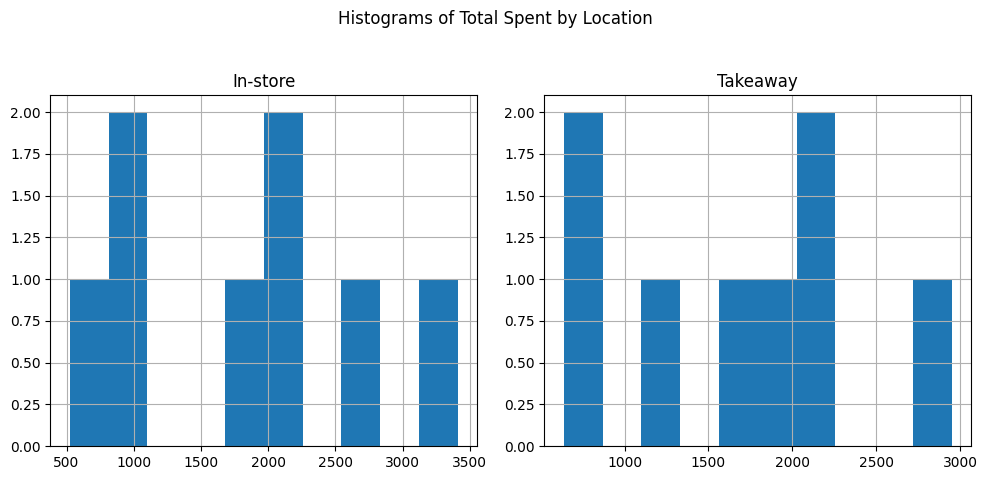

In [99]:
item_location.hist(figsize=(10, 5))
plt.suptitle('Histograms of Total Spent by Location')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

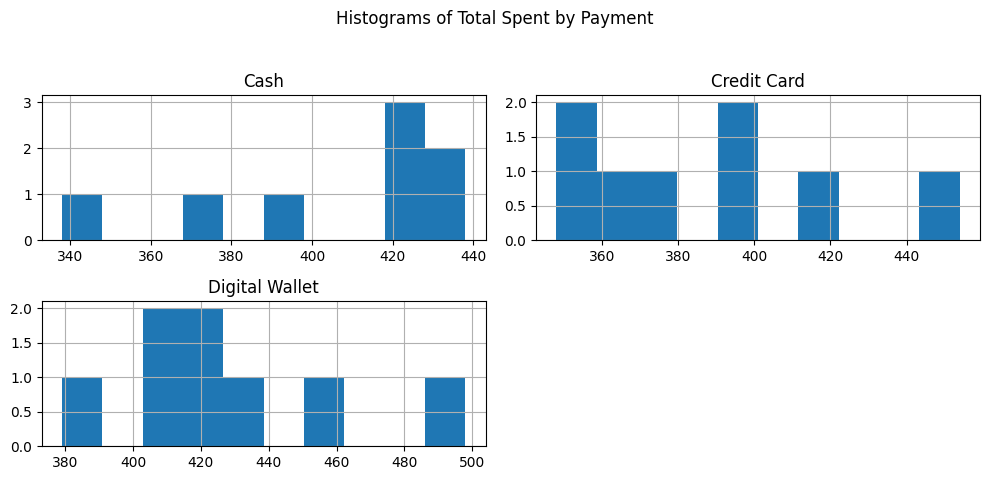

In [100]:
item_payment.hist(figsize=(10, 5))
plt.suptitle('Histograms of Total Spent by Payment')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()